In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [184]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [185]:
from df_level0 import *
from add_column_dens import *

In [99]:
def get_sub_dataset_df(sim, snap_num):
    dataset = next(sim.group_cat[snap_num].chunk_generator('subhalo'))
    keys_needed = ['SubhaloHalfmassRadType']
    sub_dict = {key: dataset[key] for key in keys_needed}
    dataset_df = utils.dfFromArrDict(sub_dict)
    return dataset_df

In [284]:
def plot_histogram(df, prop, labels=None, bins=100, log=True):
    labelsize = 55
    x_tick_major_size = 16
    x_tick_major_width = 4
    x_tick_minor_size = 8
    x_tick_minor_width = 3
    fig_width = 25
    fig_height = 15
    axes_width = 3
    tick_labelsize = 35
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    
    if prop == 'column_dens':
        x_label = r'$\log(\rho)[\log(\mathrm{gcm}^{-3})]$'
        y_label = r'p.d.f.($\log(\rho)$)'
        labels = {'x':x_label, 'y':y_label}
    elif prop == 'column_height':
        x_label = '$\log(h)[\log(\mathrm{cm})]$'
        y_label = r'p.d.f.($\log(h)$)'
        labels = {'x':x_label, 'y':y_label}
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]
    ax.hist(input_val, bins=100, density=True)
    ax.set_xlabel(labels['x'], size=labelsize)
    ax.set_ylabel(labels['y'], size=labelsize)
    plt.show();
    return

In [300]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/reduced_df_update1.pickle'
df = pd.read_pickle(df_path)

In [308]:
np.isnan(df['Masses_r']/df['M_gas_r']).sum()

3814

In [305]:
df_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/dataset_reduced.pickle'
df.to_pickle(df_path)

In [ ]:
sim, sim_path = get_sim()
z = sim.snap_cat[13].header['Redshift']
get_column_height_dens(df, z)

In [290]:
df['f_g_r'] = df['M_gas_r']/(df['M_gas_r']+df['M_star_r'])
df['f_g_2r'] = df['M_gas_2r']/(df['M_gas_2r']+df['M_star_2r'])

In [296]:
labels = {'x':'$f_g(r_{0.5\star})$', 'y':r'p.d.f.($f_g$)'}

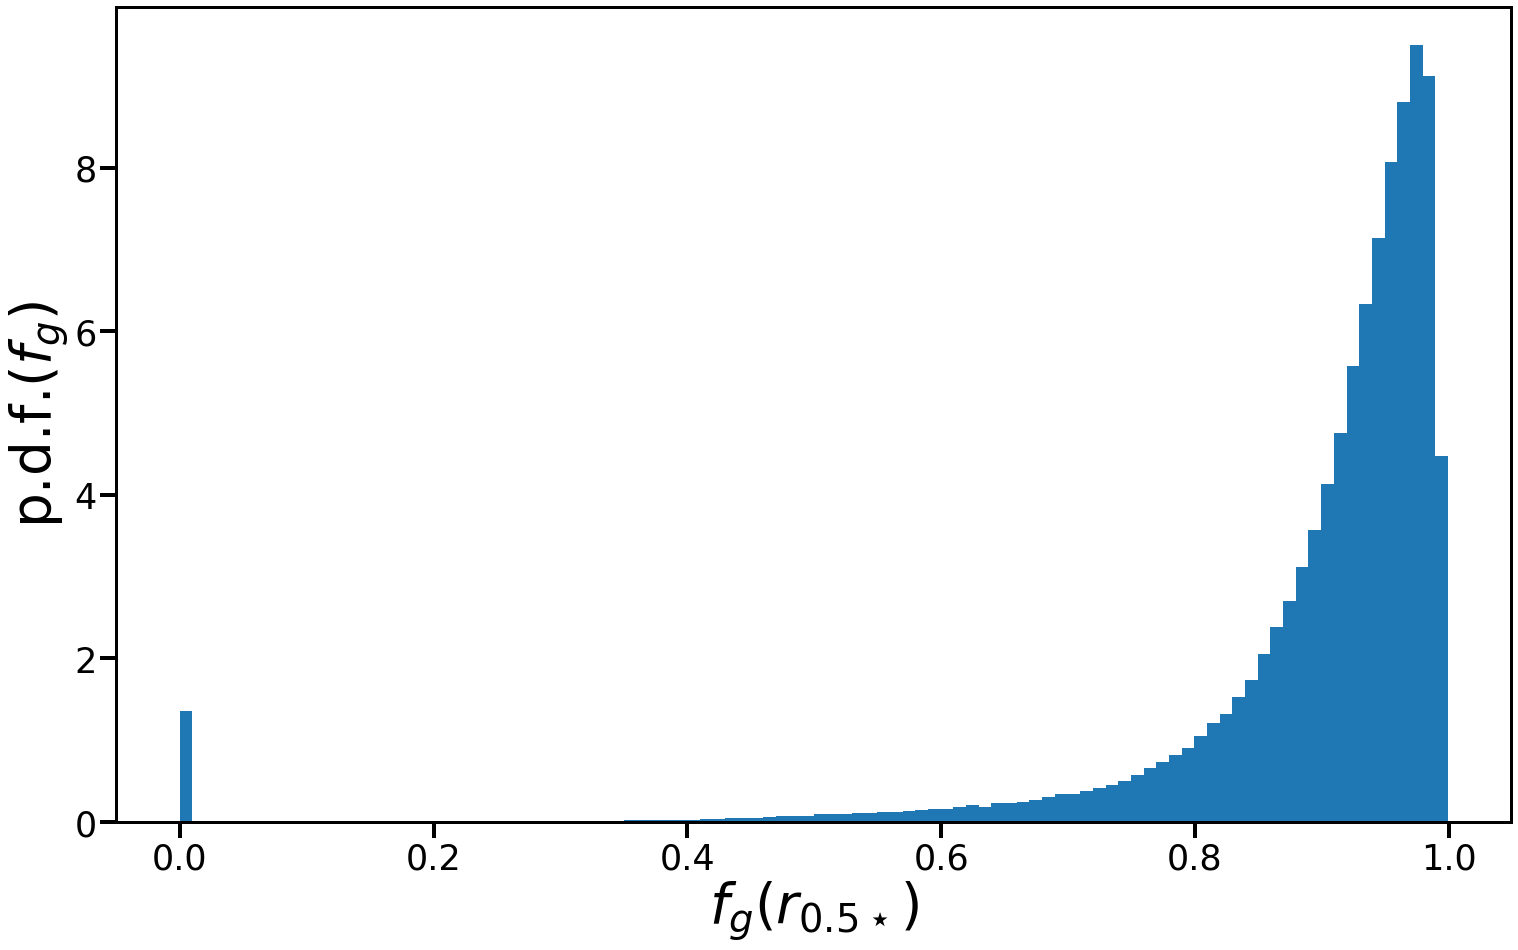

In [297]:
plot_histogram(df=df, prop='f_g_r', labels=labels, log=False)

In [298]:
labels = {'x':'$f_g(2r_{0.5\star})$', 'y':r'p.d.f.($f_g$)'}

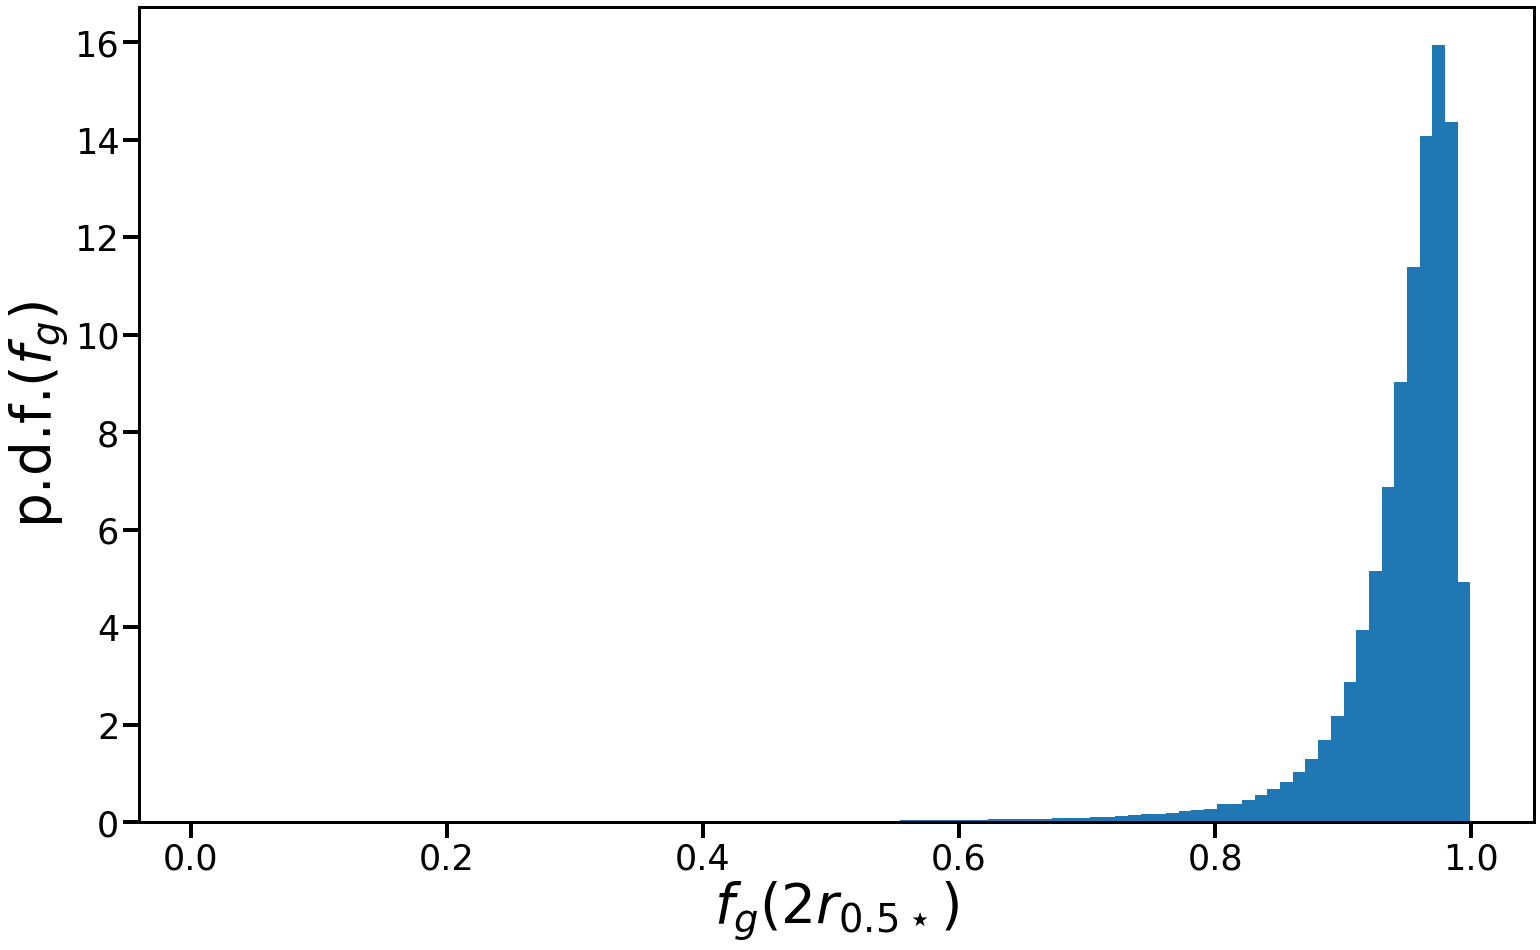

In [299]:
plot_histogram(df=df, prop='f_g_2r', labels=labels, log=False)